# Chapter 11: Ordinary Differential Equations

Companion notebook for *Python by Curiosity*. Every code listing from the chapter is
here, in the order it appears in the book, under the same title. Run the cells from
top to bottom: some listings use variables or functions defined in earlier cells.

The same listings are also available as separate scripts in `codes/listings/ch11_odes/`.

In [ ]:
# Run the listings from the repository root so that paths such as
# data/grades.csv and figures/trophy.png work.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

### Checking the one-step error of Euler's method

In [2]:
import math

k, T_room, T0 = 0.05, 20.0, 90.0          # coffee: dT/dt = -k (T - T_room)
exact = lambda t: T_room + (T0 - T_room) * math.exp(-k * t)

print(" step h   Euler T(h)   exact T(h)   error after one step")
for h in [2.0, 1.0, 0.5, 0.25]:
    slope = -k * (T0 - T_room)            # slope at the start of the step
    T_next = T0 + h * slope               # y_{n+1} = y_n + h * slope
    error = abs(T_next - exact(h))
    print(f"{h:6.2f}   {T_next:10.4f}   {exact(h):10.4f}   {error:10.5f}")

# Output:
#  step h   Euler T(h)   exact T(h)   error after one step
#   2.00      83.0000      83.3386      0.33862
#   1.00      86.5000      86.5861      0.08606
#   0.50      88.2500      88.2717      0.02169
#   0.25      89.1250      89.1304      0.00545

 step h   Euler T(h)   exact T(h)   error after one step
  2.00      83.0000      83.3386      0.33862
  1.00      86.5000      86.5861      0.08606
  0.50      88.2500      88.2717      0.02169
  0.25      89.1250      89.1304      0.00545


### Code 11.1: Euler's method from scratch

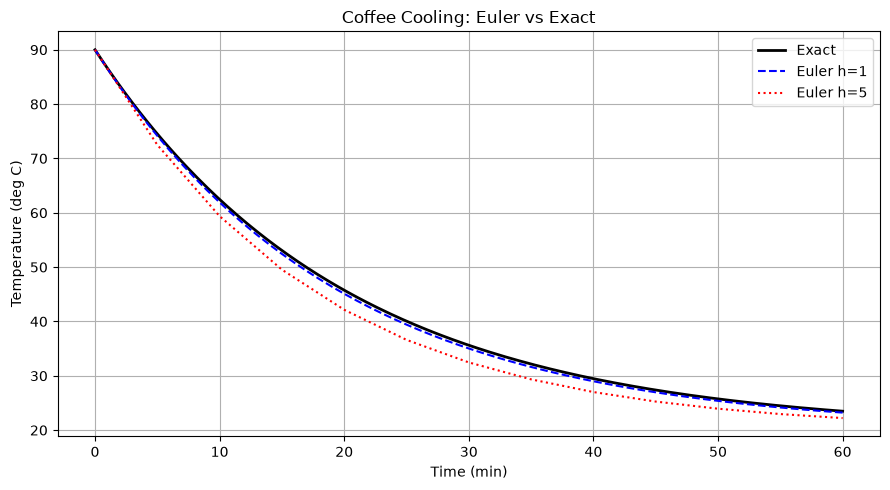

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, y0, t_start, t_end, h):
    """Solve dy/dt = f(t,y) with Euler method; step size h."""
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    return t, y

# Newton's law of cooling: dT/dt = -k*(T - T_env)
k     = 0.05      # cooling constant (per minute)
T_env = 20.0      # room temperature (deg C)
T0    = 90.0      # initial coffee temperature

f_cool = lambda t, T: -k * (T - T_env)

t_h01, T_h01 = euler(f_cool, T0, 0, 60, h=1.0)
t_h05, T_h05 = euler(f_cool, T0, 0, 60, h=5.0)

# Exact solution for comparison
t_exact = np.linspace(0, 60, 300)
T_exact = T_env + (T0 - T_env) * np.exp(-k * t_exact)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_exact, T_exact, 'k-',  lw=2,  label='Exact')
ax.plot(t_h01,   T_h01,   'b--', lw=1.5, label='Euler h=1')
ax.plot(t_h05,   T_h05,   'r:',  lw=1.5, label='Euler h=5')
ax.set_xlabel('Time (min)'); ax.set_ylabel('Temperature (deg C)')
ax.set_title('Coffee Cooling: Euler vs Exact')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.savefig('fig11-01-euler-stepsize.pdf')

### Code 11.2: Comparing step sizes

In [4]:
# Uses the euler() function from Code 11.1: run that first
import numpy as np

k     = 0.05
T_env = 20.0
T0    = 90.0
f_cool = lambda t, T: -k * (T - T_env)

for h in [5.0, 1.0, 0.1]:
    t, T = euler(f_cool, T0, 0, 60, h=h)
    # Error at t=60 min
    T_true = T_env + (T0 - T_env) * np.exp(-k * 60)
    print(f'h={h:4.1f}  T(60)={T[-1]:.4f}  error={abs(T[-1]-T_true):.4f}')

h= 5.0  T(60)=22.2173  error=1.2678
h= 1.0  T(60)=23.2249  error=0.2602
h= 0.1  T(60)=23.4590  error=0.0261


### Code 11.3: RK4 solver from scratch

In [5]:
import numpy as np

def rk4(f, y0, t_start, t_end, h):
    """Fourth-order Runge-Kutta solver."""
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        k1 = f(t[i],        y[i])
        k2 = f(t[i] + h/2,  y[i] + h/2 * k1)
        k3 = f(t[i] + h/2,  y[i] + h/2 * k2)
        k4 = f(t[i] + h,    y[i] + h   * k3)
        y[i+1] = y[i] + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, y

k     = 0.05
T_env = 20.0
T0    = 90.0
f_cool = lambda t, T: -k * (T - T_env)

t_rk4, T_rk4 = rk4(f_cool, T0, 0, 60, h=5.0)
T_true = T_env + (T0 - T_env) * np.exp(-k * 60)
err = abs(T_rk4[-1] - T_true)
print(f'RK4  h=5.0  T(60)={T_rk4[-1]:.6f}  error={err:.2e}')

RK4  h=5.0  T(60)=23.485514  error=4.19e-04


### Code 11.4: Solving ODEs with SciPy

In [6]:
import numpy as np
from scipy.integrate import solve_ivp

k     = 0.05
T_env = 20.0
T0    = 90.0
f_cool = lambda t, T: -k * (T - T_env)

# scipy uses f(t, y) returning array-like
sol = solve_ivp(f_cool, [0, 60], [T0],
                method='RK45',  # adaptive Runge-Kutta 4(5)
                dense_output=True,
                rtol=1e-8, atol=1e-10)

t_dense = np.linspace(0, 60, 300)
T_dense = sol.sol(t_dense)[0]
print('solve_ivp succeeded:', sol.success, '| steps taken:', len(sol.t))

solve_ivp succeeded: True | steps taken: 31


### Worked Example 11.1: Forward Euler RC Circuit Step Response

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants for RC electrical circuit
R = 1000.0      # Resistance (Ohms)
C = 1e-4        # Capacitance (Farads)
tau = R * C     # Time constant = 0.1 s
Vin = 5.0       # Input Voltage (V)

# Time grid setup
h = 0.01        # Step size (s)
t = np.arange(0, 0.5 + h, h)
N = len(t)

# Array allocation for voltage
V_euler = np.zeros(N)
V_euler[0] = 0.0  # Initial condition V(0) = 0

# Step 1: Forward Euler loop
for n in range(N - 1):
    dVdt = (Vin - V_euler[n]) / tau
    V_euler[n + 1] = V_euler[n] + h * dVdt

# Step 2: Analytical exact solution
V_exact = Vin * (1.0 - np.exp(-t / tau))
max_err = np.max(np.abs(V_euler - V_exact))

print(f"Time Constant tau:         {tau:.2f} s")
print(f"Euler Voltage at t=1*tau:  {V_euler[10]:.4f} V")
print(f"Exact Voltage at t=1*tau:  {V_exact[10]:.4f} V")
print(f"Maximum Discrepancy:       {max_err:.4f} V")

# Output:
# Time Constant tau:         0.10 s
# Euler Voltage at t=1*tau:  3.2566 V
# Exact Voltage at t=1*tau:  3.1606 V
# Maximum Discrepancy:       0.0960 V

Time Constant tau:         0.10 s
Euler Voltage at t=1*tau:  3.2566 V
Exact Voltage at t=1*tau:  3.1606 V
Maximum Discrepancy:       0.0960 V


### Worked Example 11.2: Classical RK4 Solver - Vertical Projectile with Air Resistance

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
g = 9.81
m = 0.2
k_drag = 0.005
v0 = 30.0

# Derivative function dv/dt = f(t, v)
def acceleration(t, v):
    return -g - (k_drag / m) * v * abs(v)

# Time grid
h = 0.1
t = np.arange(0, 2.5 + h, h)
N = len(t)
v_rk4 = np.zeros(N)
v_rk4[0] = v0

# Step 1: Classical RK4 Integration Loop
for n in range(N - 1):
    tn = t[n]
    vn = v_rk4[n]
    
    k1 = acceleration(tn, vn)
    k2 = acceleration(tn + 0.5 * h, vn + 0.5 * h * k1)
    k3 = acceleration(tn + 0.5 * h, vn + 0.5 * h * k2)
    k4 = acceleration(tn + h, vn + h * k3)
    
    v_rk4[n + 1] = vn + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

print(f"Initial Velocity:   {v_rk4[0]:.2f} m/s")
print(f"Velocity at t=1.0s: {v_rk4[10]:.4f} m/s")
print(f"Velocity at t=2.0s: {v_rk4[20]:.4f} m/s")

# Output:
# Initial Velocity:   30.00 m/s
# Velocity at t=1.0s: 10.6165 m/s
# Velocity at t=2.0s: -0.0642 m/s

Initial Velocity:   30.00 m/s
Velocity at t=1.0s: 10.6165 m/s
Velocity at t=2.0s: -0.0642 m/s


### Worked Example 11.3: SIR Epidemic Public Health Model with scipy.integrate.solve_ivp

In [9]:
import numpy as np
import scipy.integrate as integrate

# Epidemiological parameters
N_pop = 1000.0   # Total population
beta  = 0.4      # Transmission contact rate (per day)
gamma = 0.1      # Recovery / removal rate (per day)

# SIR System ODE vector function y = [S, I, R]
def sir_system(t, y):
    S, I, R = y
    dSdt = -beta * S * I / N_pop
    dIdt = (beta * S * I / N_pop) - (gamma * I)
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Initial conditions & time domain
y0 = [999.0, 1.0, 0.0]
t_span = (0.0, 60.0)
t_eval = np.linspace(0, 60, 200)

# Solve system using adaptive RK45 solver
sol = integrate.solve_ivp(sir_system, t_span, y0, t_eval=t_eval, method='RK45')

S_sol, I_sol, R_sol = sol.y
idx_peak = np.argmax(I_sol)

print(f"Basic Reproduction Number R0: {beta/gamma:.2f}")
print(f"Peak Infection Day:           {sol.t[idx_peak]:.1f} days")
print(f"Maximum Active Infection:     {I_sol[idx_peak]:.1f} cases")
print(f"Final Susceptible Remaining:  {S_sol[-1]:.1f} individuals")

# Output:
# Basic Reproduction Number R0: 4.00
# Peak Infection Day:           27.1 days
# Maximum Active Infection:     403.5 cases
# Final Susceptible Remaining:  22.9 individuals

Basic Reproduction Number R0: 4.00
Peak Infection Day:           27.1 days
Maximum Active Infection:     403.5 cases
Final Susceptible Remaining:  22.9 individuals


### Worked Example 11.4: 2nd-Order Non-linear Damped Pendulum ODE System

In [10]:
import numpy as np
import scipy.integrate as integrate

g = 9.81
L = 1.0
gamma = 0.25

# 2-variable state vector y = [theta, omega]
def pendulum_system(t, y):
    theta, omega = y
    dtheta_dt = omega
    domega_dt = -gamma * omega - (g / L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

y0 = [np.pi / 2.0, 0.0]  # Initial state: 90 deg release from rest
t_span = (0.0, 10.0)
t_eval = np.linspace(0, 10, 300)

sol = integrate.solve_ivp(pendulum_system, t_span, y0, t_eval=t_eval, method='RK45')
theta_res, omega_res = sol.y

print(f"Initial Angle:        {np.degrees(theta_res[0]):.1f} deg")
print(f"First Swing Peak:     {np.degrees(np.min(theta_res)):.1f} deg")
print(f"Max Angular Velocity: {np.max(np.abs(omega_res)):.4f} rad/s")

# Output:
# Initial Angle:        90.0 deg
# First Swing Peak:     -76.3 deg
# Max Angular Velocity: 4.1335 rad/s

Initial Angle:        90.0 deg
First Swing Peak:     -76.3 deg
Max Angular Velocity: 4.1335 rad/s


### Real-World Solution

In [11]:
import numpy as np

def rk4(f, y0, t_start, t_end, h):
    """Fourth-order Runge-Kutta solver (Code 11.3)."""
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        k1 = f(t[i],        y[i])
        k2 = f(t[i] + h/2,  y[i] + h/2 * k1)
        k3 = f(t[i] + h/2,  y[i] + h/2 * k2)
        k4 = f(t[i] + h,    y[i] + h   * k3)
        y[i+1] = y[i] + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return t, y

T_room, T0 = 20.0, 90.0

# Step 1: the measurement T(5) = 70 fixes the cooling constant k
k = np.log((T0 - T_room) / (70.0 - T_room)) / 5.0
print(f"Cooling constant k = {k:.4f} per minute")

# Step 2: step forward with RK4 and find the first time T <= 40
f_cool = lambda t, T: -k * (T - T_room)
t, T = rk4(f_cool, T0, 0, 60, h=0.01)
first = np.argmax(T <= 40.0)          # index of the first True
print(f"RK4: coffee reaches 40 C after about {t[first]:.1f} minutes")

# Step 3: check against the exact solution T = 20 + 70 exp(-k t)
t_exact = np.log((T0 - T_room) / (40.0 - T_room)) / k
print(f"Exact formula gives {t_exact:.1f} minutes")

# Output:
# Cooling constant k = 0.0673 per minute
# RK4: coffee reaches 40 C after about 18.6 minutes
# Exact formula gives 18.6 minutes

Cooling constant k = 0.0673 per minute
RK4: coffee reaches 40 C after about 18.6 minutes
Exact formula gives 18.6 minutes
